In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [5]:
# lectura dataset
from sklearn.datasets import make_blobs 

X, y = make_blobs(n_samples=1000, centers=10, random_state=0,cluster_std=1.5)

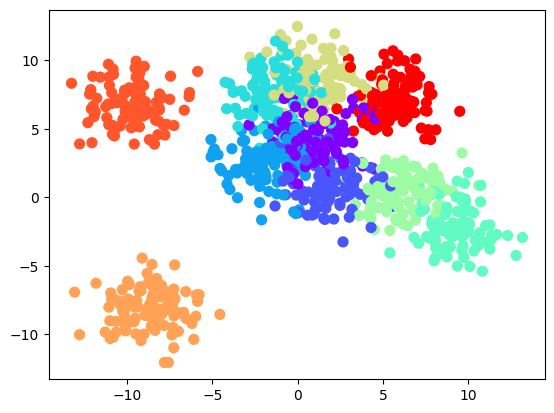

In [9]:
# graficando X e Y 
plt.scatter(X[:,0], X[:, 1], c=y, s=50, cmap="rainbow")

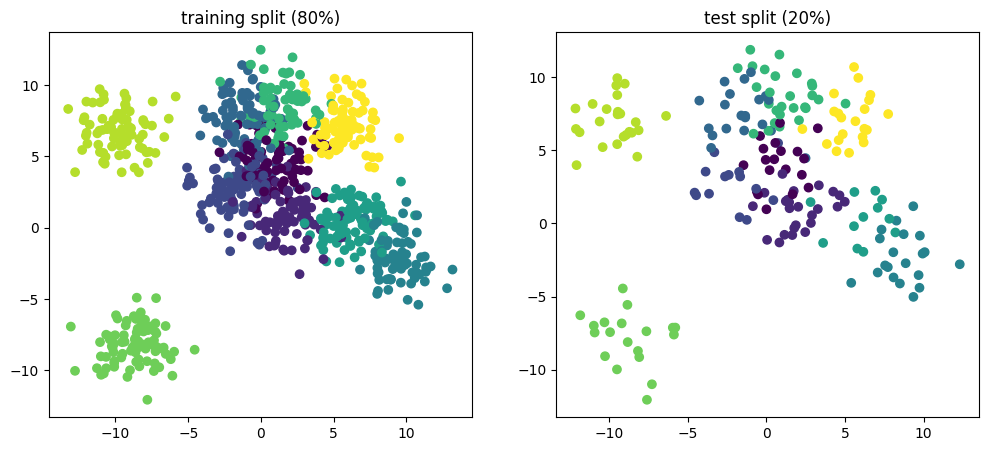

In [22]:
# separando data en entrenamiento y testeo 
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# graficando datos de entrenamiento y testeo 

fig,axes = plt.subplots(1,2, figsize=(12,5))
# train
axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train)
axes[0].set_title("training split (80%)")
# test
axes[1].scatter(X_test[:, 0], X_test[:,1], c=y_test)
axes[1].set_title("test split (20%)")

plt.show()

In [23]:
# funcion para visualizar la clasificacion 
def visualize_classifier(model, X, Y, ax=None, cmap='rainbow'):

  ax = ax or plt.gca()
  ax.scatter(X[:, 0], X[:, 1], c=Y, s=30, cmap=cmap, clim=(Y.min(), Y.max()), zorder=3)

  ax.axis('tight')
  ax.axis('off')
  xlim = ax.get_xlim()
  ylim = ax.get_ylim()


  xx, yy = np.meshgrid(np.linspace(*xlim, num=200), np.linspace(*ylim, num=200))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

  # Create a color plot with the results
  n_classes = len(np.unique(Y))
  contours = ax.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(n_classes + 1) - 0.5, cmap=cmap, zorder=1)

  ax.set(xlim=xlim, ylim=ylim)

Confusion matrix:
 [[ 9  6  2  2  0  0  0  0  0  0]
 [ 1 17  3  0  0  3  0  0  0  0]
 [ 1  2 11  0  0  0  0  0  0  0]
 [ 3  0  1 13  0  0  3  0  0  0]
 [ 0  0  0  0 18  2  0  0  0  0]
 [ 0  1  0  0  2  9  0  0  0  0]
 [ 3  0  0  8  0  0 14  0  0  2]
 [ 0  0  0  0  0  0  0 18  1  0]
 [ 0  0  0  0  0  0  0  0 24  0]
 [ 3  0  0  1  0  0  1  0  0 16]]
Accuracy: 0.745
Max depth: 16



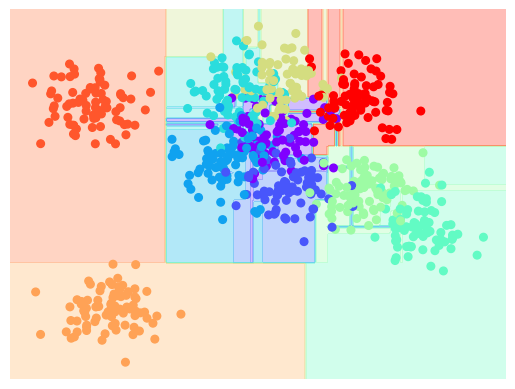

In [30]:
# crear el modelo 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score

# implementar y entrenar modelo
tree_model = DecisionTreeClassifier(max_depth=20)
tree_model.fit(X_train,y_train)

# prediccion
y_hat = tree_model.predict(X_test)

# metricas 
print(f'Confusion matrix:\n {confusion_matrix(y_test, y_hat)}')
print(f'Accuracy: {accuracy_score(y_test, y_hat)}')
print(f'Max depth: {tree_model.get_depth()}')
print()
visualize_classifier(tree_model, X_train, y_train)

Confusion matrix:
 [[11  2  3  1  0  0  2  0  0  0]
 [ 2 15  3  0  0  4  0  0  0  0]
 [ 0  1 12  0  0  0  1  0  0  0]
 [ 1  0  0 16  0  0  3  0  0  0]
 [ 0  0  0  0 17  3  0  0  0  0]
 [ 0  2  0  0  2  8  0  0  0  0]
 [ 1  0  0  6  0  0 19  0  0  1]
 [ 0  0  0  0  0  0  0 18  1  0]
 [ 0  0  0  0  0  0  0  0 24  0]
 [ 2  0  0  0  0  0  1  0  0 18]]
Accuracy: 0.79
best depth : DecisionTreeClassifier(max_depth=7)


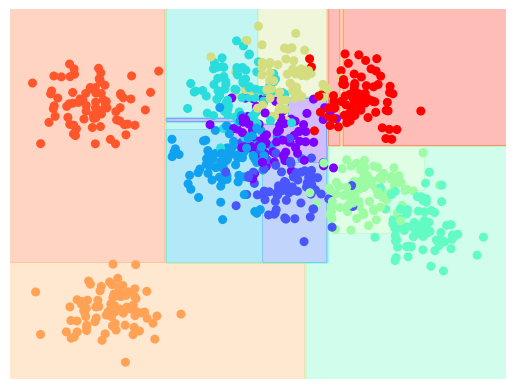

In [43]:
# aplicar  grid search cv 
from sklearn.model_selection import GridSearchCV

# implementar hyperparametros
hyperparameters = {
    'max_depth' : [1,3,6,7,8],
    'criterion': ['gini', 'entropy']
}

# implemnetar modelo entrenado por grid 
tree = DecisionTreeClassifier()
grid = GridSearchCV(tree, hyperparameters).fit(X_train,y_train)

# prediccion
y_hat = grid.predict(X_test)

# metricas 
print(f'Confusion matrix:\n {confusion_matrix(y_test, y_hat)}')
print(f'Accuracy: {accuracy_score(y_test, y_hat)}')
print(f'best depth : {grid.best_estimator_}')
visualize_classifier(grid, X_train, y_train)

In [45]:
# Regresion con arboles 
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

In [46]:
# Fit regression model
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor()
regr_3 = GridSearchCV(DecisionTreeRegressor(), [{'max_depth': [1,2,3,5,7,10,15,20]}])

regr_1.fit(X, y)
regr_2.fit(X, y)
regr_3.fit(X, y);

In [47]:
# Predict
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)
y_3 = regr_3.predict(X_test)

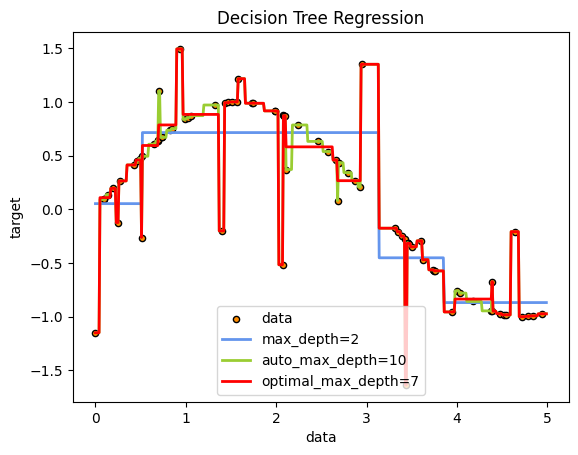

In [48]:
# Plot the results
plt.figure()
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label=f'auto_max_depth={regr_2.get_depth()}', linewidth=2)
plt.plot(X_test, y_3, color="red", label=f'optimal_max_depth={regr_3.best_estimator_.get_depth()}', linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()